# Autoencoder Evaluation Framework

## Imports

In [1]:
import sys
sys.path.append('./train_aautoencoders/')

sys.path.append('./results_plotting')

import torch
#import torchvision
#from torchvision import transforms, datasets
#from torchvision.datasets import FashionMNIST
#import matplotlib
import matplotlib.pyplot as plt
#import os
from torch import nn
import torch.nn.functional as F
import numpy as np
from datasets import getDataset, get_train_test_datasets_and_data_in_batches, get_shuffeled_labels_after_imbalancing, get_dataset_class_stats
#from dataset_imbalancing import create_data_imbalance

from models import AE, CNN_AE_fmnist, Autoencoder_linear_contra_fmnist, MLP_VAE_fmnist, CNN_VAE_fmnist, CNN_AE_fmnist_noiser, CNN_AE_fmnist_noiser_sig, CNN_AE_fmnist_noiser_2sig
from plotting_functions import get_batch_psnr_ssim_lists, get_perturbed_samples
from tqdm import tqdm 
from activations import Sin

torch.manual_seed(0)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

path_models = './saved_models/'

## Loading configurations

In [2]:
classes = ["T-shirt-top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]
class_labels = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
number_of_classes =len(class_labels)


test_majority_class_index = 8 # the class of which you want the reconstructions

In [3]:
test_majority_class_frac = 0.1 # fix this value
general_class_frac_in_test = (1.0 - test_majority_class_frac)/(len(class_labels)-1)
test_class_fracs = [general_class_frac_in_test for i in range(number_of_classes)]
test_class_fracs[test_majority_class_index] = test_majority_class_frac 

#used during trainig
majority_class_index = 9   # set which is the ,majority class during training
majority_class_frac = 1.0

#for majority_class_frac in majority_class_fracs:

general_class_frac = (10.0 - majority_class_frac)/(len(class_labels)-1)
train_class_fracs = [general_class_frac for i in range(number_of_classes)]
train_class_fracs[majority_class_index] = majority_class_frac

psnr_list_of_lists = []
ssim_list_of_lists = []


#for test_majority_class_index in class_labels:



#Select the autoencoder you want the plots for
train_AE_MLP= False
train_AE_REG = False
train_CNN_AE = False
train_Contra_AE = False
train_MLPVAE= False
train_CNN_VAE = True

#Check if you want perturbed inputs
perturb_test_data = False
test_data_noise_percent = 0.1

print('train_class_fracs', train_class_fracs )
print('test_class_fracs', test_class_fracs )

dataset = "MNIST"
set_batch_size = 200
train_batches, test_batches, no_channels, dx, dy = get_train_test_datasets_and_data_in_batches(train_class_fracs, test_class_fracs, set_batch_size, dataset)

test_samples = test_batches.reshape(test_batches.shape[0]*test_batches.shape[1], no_channels, dx, dy).to(device)

print('test_samples.shape', test_samples.shape)
if(perturb_test_data):
    test_samples = get_perturbed_samples(test_samples, test_data_noise_percent, no_channels, dx, dy, device)
else:
    test_data_noise_percent = 0.0
print('perturbed_samples.shape', test_samples.shape)

# To check the population of different classes in train and test datasets
get_dataset_class_stats(train_class_fracs, test_class_fracs, class_labels, dataset)

train_class_fracs [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
test_class_fracs [0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1]
test_samples.shape torch.Size([800, 1, 32, 32])
perturbed_samples.shape torch.Size([800, 1, 32, 32])
Checking class populations after shuffling in train data
Size of class  : 0 torch.Size([5923])
Size of class  : 1 torch.Size([6742])
Size of class  : 2 torch.Size([5958])
Size of class  : 3 torch.Size([6131])
Size of class  : 4 torch.Size([5842])
Size of class  : 5 torch.Size([5421])
Size of class  : 6 torch.Size([5918])
Size of class  : 7 torch.Size([6265])
Size of class  : 8 torch.Size([5851])
Size of class  : 9 torch.Size([5949])

total train data size :  60000
Checking class populations after shuffling in test data
Size of class: 0 torch.Size([98])
Size of class: 1 torch.Size([113])
Size of class: 2 torch.Size([103])
Size of class: 3 torch.Size([101])
Size of class: 4 torch.Size([98])
Size of class: 5 torch.Size([89])
Size of class: 6 torch.Size([9

# Get class clusters in test test

In [4]:
import torch
import torchvision
from torchvision import transforms, datasets

def getMNIST(batch_size = 1, drop_last=False):
    fashionmnist_data = torchvision.datasets.MNIST(download=True, root = 'data/mnist', transform = 
                                                                                 transforms.Compose([transforms.Resize(32),
                                                                                 transforms.ToTensor(), 
                                                                                 transforms.Lambda(lambda x: x.repeat(1, 1, 1))
                                                                                 ]))

    fashionmnist_data_test = torchvision.datasets.MNIST(download=True, root = 'data/mnist', train=False, transform = 
                                                                                 transforms.Compose([transforms.Resize(32),
                                                                                 transforms.ToTensor(), 
                                                                                 transforms.Lambda(lambda x: x.repeat(1, 1, 1))
                                                                                 ]))

    train_loader = torch.utils.data.DataLoader(fashionmnist_data,
                                              batch_size=batch_size,
                                              shuffle=False,
                                              num_workers=16,
                                              drop_last=drop_last)

    test_loader = torch.utils.data.DataLoader(fashionmnist_data_test,
                                              batch_size=batch_size,
                                              shuffle=False,
                                              num_workers=16,
                                              drop_last=drop_last)

    return train_loader, test_loader


def getDataset(dataset = "MNIST", batch_size = 1):
    if(dataset == "MNIST"):
        train_loader, test_loader = getMNIST(batch_size)
        noChannels,dx, dy = train_loader.dataset.__getitem__(1)[0].shape
    elif(dataset == "FashionMNIST"):
        train_loader, test_loader = getFashionMNIST(batch_size)
        noChannels, dx, dy = train_loader.dataset.__getitem__(1)[0].shape
    elif(dataset == "Cifar10"):
        train_loader, test_loader = getCifar10(batch_size)
        noChannels, dx, dy = train_loader.dataset.__getitem__(1)[0].shape
    else:
        return None, None, None, None, None    
        
    return train_loader, test_loader, noChannels, dx, dy

In [5]:
train_loader, test_loader, no_channels, dx, dy = getDataset(dataset, batch_size = 60000)  # FashionMNIST , MNIST

In [6]:


for i, (images, label) in enumerate(train_loader):

    cl_0_labels = label[label==0]
    class_0_images = images[label==0]

    cl_1_labels = label[label==1]
    class_1_images = images[label==1]

    cl_2_labels = label[label==2]
    class_2_images = images[label==2]

    cl_3_labels = label[label==3]
    class_3_images = images[label==3]

    cl_4_labels = label[label==4]
    class_4_images = images[label==4]

    cl_5_labels = label[label==5]
    class_5_images = images[label==5]

    cl_6_labels = label[label==6]
    class_6_images = images[label==6]

    cl_7_labels = label[label==7]
    class_7_images = images[label==7]

    cl_8_labels = label[label==8]
    class_8_images = images[label==8]

    cl_9_labels = label[label==9]
    class_9_images = images[label==9]


    break

In [7]:
class_0_images.shape

torch.Size([5923, 1, 32, 32])

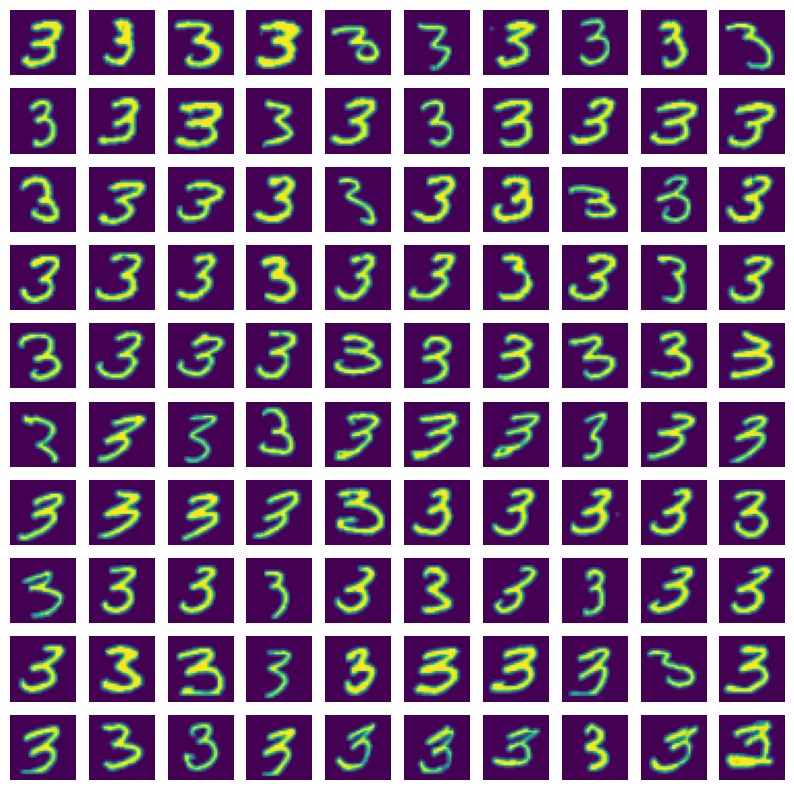

In [8]:
import matplotlib.pyplot as plt
with torch.no_grad():
    fig = plt.figure(figsize=(10,10))
    for i in range(100):
        plt.subplot(10, 10,i+1)
        plt.imshow(class_3_images[i][0].cpu().numpy())
        plt.axis('off')
    plt.show()

## Loading parameters

In [9]:
# Common hyper parameters
layer_size = 100
latent_dim = 4
no_layers = 3
no_epochs = 100
inp_dim = [no_channels, dx, dy]


#parameters specific to MLPAE
activation_mlpae = Sin()
lr_mlpae = 0.0001



# parameters specific for jacobian regularized autoencoders
activation_aereg = Sin()
lr_aereg = 0.0001
deg_poly = 21
use_guidance = False
alpha = 0.5
no_samples = 10
reg_nodes_sampled = "legendre"
if(reg_nodes_sampled == "legendre"):
    points = np.polynomial.legendre.leggauss(deg_poly)[0][::-1]
    weights = np.polynomial.legendre.leggauss(deg_poly)[1][::-1]

if(reg_nodes_sampled == "chebyshev"):
    points = np.polynomial.chebyshev.chebgauss(deg_poly)[0][::-1]
    weights = np.polynomial.chebyshev.chebgauss(deg_poly)[1][::-1]


# parameters specific to CNN-AE
activation_cnn = torch.nn.ReLU()
lr_cnn = 1e-3
weight_decay_cnn = 1e-5


# Parameters specific to Contra AE
lam_contra = 1e-2
lr_contra = 1e-3
weight_decay_contra = 1e-5
activation_contra = torch.nn.ReLU()



# Parameters specific to MLP-VAE
lr_mlpvae = 1e-3
activation_mlpvae = torch.nn.ReLU()


# Parameters specific to CNN-VAE
lr_cnn_vae = 0.0001
h_dim_cnn_vae = 8*2*2
activation_cnn_vae = torch.nn.ReLU()

In [10]:
########################################################################################################################
# Loading models
########################################################################################################################

# loading MLPAE
if(train_AE_MLP):
    model_mlpae = AE(inp_dim, layer_size, latent_dim, no_layers, activation_mlpae).to(device) # baseline autoencoder
    name_mlpae = '_'+"MLP-AE"+'_'+str(no_layers)+'_'+str(layer_size)+'_'+str(latent_dim)+'_'+str(lr_mlpae)+'_'+str(activation_mlpae)+'_'+str(dataset)+'_'+str(number_of_classes)+'_'+str(majority_class_index)+'_'+str(majority_class_frac)+'_'+str(no_epochs)+'_'+str(set_batch_size)
    model_mlpae.load_state_dict(torch.load(path_models+'/model'+name_mlpae, map_location=device))

    reconstructions_mlpae = model_mlpae(test_samples).view(test_samples.size())
    #psnr_of_samples, ssim_of_samples =  get_batch_psnr_ssim_lists(test_samples, reconstructions_mlpae)

########################################################################################################################


# Loading AE-REG
########################################################################################################################
if(train_AE_REG):
    model_aereg = AE(inp_dim, layer_size, latent_dim, no_layers, activation_aereg).to(device) # baseline autoencoder
    name_aereg = '_'+"AE-REG"+'_'+str(no_layers)+'_'+str(layer_size)+'_'+str(latent_dim)+'_'+ str(reg_nodes_sampled)+'_'+ str(deg_poly)+'_'+ str(alpha)+'_'+ str(no_samples)+'_'+str(lr_aereg)+'_'+str(activation_aereg)+'_'+str(dataset)+'_'+str(number_of_classes)+'_'+str(majority_class_index)+'_'+str(majority_class_frac)+'_'+str(no_epochs)+'_'+str(set_batch_size)
    model_aereg.load_state_dict(torch.load(path_models+'/model'+name_aereg, map_location=device))

    reconstructions_aereg = model_aereg(test_samples).view(test_samples.size())
    #psnr_of_samples, ssim_of_samples =  get_batch_psnr_ssim_lists(test_samples, reconstructions_aereg)

########################################################################################################################


# Loading CNN-AE
########################################################################################################################
if(train_CNN_AE):
    model_cnnae = CNN_AE_fmnist(latent_dim, no_channels, activation_cnn).to(device)
    name_cnnae = '_'+"CNN-AE"+'_'+str(no_layers)+'_'+str(layer_size)+'_'+str(latent_dim)+'_'+str(lr_cnn)+'_'+str(activation_cnn)+'_'+str(dataset)+'_'+str(number_of_classes)+'_'+str(majority_class_index)+'_'+str(majority_class_frac)+'_'+str(no_epochs)+'_'+str(set_batch_size)+'_'+str(weight_decay_cnn)
    model_cnnae.load_state_dict(torch.load(path_models+'/model'+name_cnnae, map_location=device))

    reconstructions_cnnae = model_cnnae(test_samples).view(test_samples.size())
    #psnr_of_samples, ssim_of_samples =  get_batch_psnr_ssim_lists(test_samples, reconstructions_cnnae)

########################################################################################################################

# Loading ContraAE
########################################################################################################################
if(train_Contra_AE):
    model_contra_ = Autoencoder_linear_contra_fmnist(latent_dim, no_channels, dx, dy, layer_size, activation_contra).to(device)
    name_contra = '_'+"ContraAE"+'_'+str(no_layers)+'_'+str(layer_size)+'_'+str(latent_dim)+'_'+str(lr_contra)+'_'+str(activation_contra)+'_'+str(dataset)+'_'+str(number_of_classes)+'_'+str(majority_class_index)+'_'+str(majority_class_frac)+'_'+str(no_epochs)+'_'+str(set_batch_size)+'_'+str(weight_decay_contra)+'_'+str(lam_contra)
    model_contra_.load_state_dict(torch.load(path_models+'/model'+name_contra, map_location=device))
    def model_contra(batch_x):
        batch_x_in = batch_x.reshape(-1, dx*dy).to(device)    
        return model_contra_(batch_x_in)

    reconstructions_contra = model_contra(test_samples).view(test_samples.size())
    #psnr_of_samples, ssim_of_samples =  get_batch_psnr_ssim_lists(test_samples, reconstructions_contra)

    
########################################################################################################################

# Loading MLP-VAE
########################################################################################################################
if(train_MLPVAE):
    model_mlpvae_ = MLP_VAE_fmnist(dx*dy, layer_size, latent_dim, activation_mlpvae).to(device)
    name_mlpvae = '_'+"MLP-VAE"+'_'+str(no_layers)+'_'+str(layer_size)+'_'+str(latent_dim)+'_'+str(lr_mlpvae)+'_'+str(activation_mlpvae)+'_'+str(dataset)+'_'+str(number_of_classes)+'_'+str(majority_class_index)+'_'+str(majority_class_frac)+'_'+str(no_epochs)+'_'+str(set_batch_size)
    model_mlpvae_.load_state_dict(torch.load(path_models+'/model'+name_mlpvae, map_location=device))
    def model_mlpvae(batch_x):
        batch_x_in = batch_x.reshape(-1, dx*dy).to(device)    
        recon, _, _ = model_mlpvae_(batch_x_in)
        return recon
    
    reconstructions_mlpvae = model_mlpvae(test_samples).view(test_samples.size())
    #psnr_of_samples, ssim_of_samples =  get_batch_psnr_ssim_lists(test_samples, reconstructions_mlpvae)

########################################################################################################################

# Loading CNN-VAE
########################################################################################################################
if(train_CNN_VAE):
    model_cnnvae_ = CNN_VAE_fmnist(no_channels, no_layers, activation_cnn_vae, h_dim_cnn_vae, z_dim=latent_dim).to(device)
    name_cnnvae = '_'+"CNN-VAE"+'_'+str(no_layers)+'_'+str(layer_size)+'_'+str(latent_dim)+'_'+str(lr_cnn_vae)+'_'+str(activation_cnn_vae)+'_'+str(dataset)+'_'+str(number_of_classes)+'_'+str(majority_class_index)+'_'+str(majority_class_frac)+'_'+str(no_epochs)+'_'+str(set_batch_size)
    model_cnnvae_.load_state_dict(torch.load(path_models+'/model'+name_cnnvae, map_location=device))

    def model_cnnvae(batch_x):
        recon, _, _ = model_cnnvae_(batch_x)
        return recon

    reconstructions_cnnvae = model_cnnvae(test_samples).view(test_samples.size())
    #psnr_of_samples, ssim_of_samples =  get_batch_psnr_ssim_lists(test_samples, reconstructions_cnnvae)

In [11]:
# all reconstructions

#print("reconstructions_mlpae.shape", reconstructions_mlpae.shape)
#print("reconstructions_aereg.shape", reconstructions_aereg.shape)
#print("reconstructions_cnnae.shape", reconstructions_cnnae.shape)
#print("reconstructions_contra.shape", reconstructions_contra.shape)
#print("reconstructions_mlpvae.shape", reconstructions_mlpvae.shape)
print("reconstructions_cnnvae.shape", reconstructions_cnnvae.shape)

reconstructions_cnnvae.shape torch.Size([800, 1, 32, 32])


Experiment 1 : Train a noiser to generate perturbtions for class 0 to be reconstructed as class 1

In [12]:
# Fixing input and target


input_image = class_1_images[0]
target_image = class_9_images[0]

In [13]:
input_image.shape, target_image.shape

(torch.Size([1, 32, 32]), torch.Size([1, 32, 32]))

In [14]:
class_9_images.shape

torch.Size([5949, 1, 32, 32])

In [15]:
num_epochs = 35000
from torch import nn

activation_cnn_noiser = nn.ReLU()

input_class = 7
target_class = input_class
adv_class = 9

# what works# (7, 7, 0, 0.7) , (1, 1, 0, 0.7), (8, 8, 0, 0.7), (8, 8, 0, 0.3), (5, 5, 9, 0.7)

# what did not works : (1, 1, 5, 0.7), (5, 5, 0, 0.6), (0, 0, 5, 0.9)


end_index_in_input_batch = 1000
end_index_in_output_batch = 1000

'''for input_class in range(10):
    for target_class in range(10):
        if (input_class != target_class):
            here_batch = 200
            #train_batches = train_batches.reshape(-1, here_batch, no_channels, dx, dy).to(device)'''
here_batch_size = 50


if(input_class == 0):
    train_batches = class_0_images[:end_index_in_input_batch].reshape(-1, here_batch_size, no_channels, dx, dy).to(device)
if(input_class == 1):
    train_batches = class_1_images[:end_index_in_input_batch].reshape(-1, here_batch_size, no_channels, dx, dy).to(device)
if(input_class == 2):
    train_batches = class_2_images[:end_index_in_input_batch].reshape(-1, here_batch_size, no_channels, dx, dy).to(device)
if(input_class == 3):
    train_batches = class_3_images[:end_index_in_input_batch].reshape(-1, here_batch_size, no_channels, dx, dy).to(device)
if(input_class == 4):
    train_batches = class_4_images[:end_index_in_input_batch].reshape(-1, here_batch_size, no_channels, dx, dy).to(device)
if(input_class == 5):
    train_batches = class_5_images[:end_index_in_input_batch].reshape(-1, here_batch_size, no_channels, dx, dy).to(device)
if(input_class == 6):
    train_batches = class_6_images[:end_index_in_input_batch].reshape(-1, here_batch_size, no_channels, dx, dy).to(device)
if(input_class == 7):
    train_batches = class_7_images[:end_index_in_input_batch].reshape(-1, here_batch_size, no_channels, dx, dy).to(device)
if(input_class == 8):
    train_batches = class_8_images[:end_index_in_input_batch].reshape(-1, here_batch_size, no_channels, dx, dy).to(device)
if(input_class == 9):
    train_batches = class_9_images[:end_index_in_input_batch].reshape(-1, here_batch_size, no_channels, dx, dy).to(device)

print("train_batches.shape", train_batches.shape)

if(target_class == 0):
    target = class_0_images[:end_index_in_output_batch].reshape(-1, here_batch_size, no_channels, dx, dy).to(device)
if(target_class == 1):
    target = class_1_images[:end_index_in_output_batch].reshape(-1, here_batch_size, no_channels, dx, dy).to(device)
if(target_class == 2):
    target = class_2_images[:end_index_in_output_batch].reshape(-1, here_batch_size, no_channels, dx, dy).to(device)
if(target_class == 3):
    target = class_3_images[:end_index_in_output_batch].reshape(-1, here_batch_size, no_channels, dx, dy).to(device)
if(target_class == 4):
    target = class_4_images[:end_index_in_output_batch].reshape(-1, here_batch_size, no_channels, dx, dy).to(device)
if(target_class == 5):
    target = class_5_images[:end_index_in_output_batch].reshape(-1, here_batch_size, no_channels, dx, dy).to(device)
if(target_class == 6):
    target = class_6_images[:end_index_in_output_batch].reshape(-1, here_batch_size, no_channels, dx, dy).to(device)
if(target_class == 7):
    target = class_7_images[:end_index_in_output_batch].reshape(-1, here_batch_size, no_channels, dx, dy).to(device)
if(target_class == 8):
    target = class_8_images[:end_index_in_output_batch].reshape(-1, here_batch_size, no_channels, dx, dy).to(device)
if(target_class == 9):
    target = class_9_images[:end_index_in_output_batch].reshape(-1, here_batch_size, no_channels, dx, dy).to(device)



if(adv_class == 0):
    print("class_0_images.shape", class_0_images.shape)
    adv_batches = class_0_images[:end_index_in_input_batch].reshape(-1, here_batch_size, no_channels, dx, dy).to(device)
if(adv_class == 1):
    adv_batches = class_1_images[:end_index_in_input_batch].reshape(-1, here_batch_size, no_channels, dx, dy).to(device)
if(adv_class == 2):
    adv_batches = class_2_images[:end_index_in_input_batch].reshape(-1, here_batch_size, no_channels, dx, dy).to(device)
if(adv_class == 3):
    adv_batches = class_3_images[:end_index_in_input_batch].reshape(-1, here_batch_size, no_channels, dx, dy).to(device)
if(adv_class == 4):
    adv_batches = class_4_images[:end_index_in_input_batch].reshape(-1, here_batch_size, no_channels, dx, dy).to(device)
if(adv_class == 5):
    adv_batches = class_5_images[:end_index_in_input_batch].reshape(-1, here_batch_size, no_channels, dx, dy).to(device)
if(adv_class == 6):
    adv_batches = class_6_images[:end_index_in_input_batch].reshape(-1, here_batch_size, no_channels, dx, dy).to(device)
if(adv_class == 7):
    adv_batches = class_7_images[:end_index_in_input_batch].reshape(-1, here_batch_size, no_channels, dx, dy).to(device)
if(adv_class == 8):
    adv_batches = class_8_images[:end_index_in_input_batch].reshape(-1, here_batch_size, no_channels, dx, dy).to(device)
if(adv_class == 9):
    adv_batches = class_9_images[:end_index_in_input_batch].reshape(-1, here_batch_size, no_channels, dx, dy).to(device)

train_batches.shape torch.Size([20, 50, 1, 32, 32])


In [16]:
adv_batches.shape

torch.Size([20, 50, 1, 32, 32])

In [17]:
num_noisers = 11

avd_alphas = np.linspace(0.0, 1.0, num_noisers)
avd_alphas = avd_alphas[1:]
avd_alphas

array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ])

In [18]:
adv_alpha = 0.85
#for adv_alpha in avd_alphas:
autoenoiser_cnn = CNN_AE_fmnist_noiser_2sig(latent_dim, no_channels, activation_cnn_noiser).to(device)
criterion = nn.MSELoss()
import torch.optim as optim
optimizer = optim.Adam(autoenoiser_cnn.parameters(), lr=0.0001)

train_batches_ = train_batches

#train_batches = gen_tens

In [19]:

for epoch in range(num_epochs):
    t_i = 0
    for data in train_batches_:
        optimizer.zero_grad()
        data = data.to(device)
        noise_outputs = autoenoiser_cnn(data)
        noise_outputs = (noise_outputs - 1.0)*2.0
        adv_gen,_,_ = model_cnnvae_(data + noise_outputs)


        #ae_perturbed_embeds = model_cnnvae_.encoder(adv_gen) # some confusion here. Why are you doin whatever you doing . Should not the input be  data + noise_outputs ?
        ae_perturbed_embeds = model_cnnvae_.encoder(data + noise_outputs) # some confusion here. Why are you doin whatever you doing . Should not the input be  data + noise_outputs ?
        mu1, logvar = model_cnnvae_.fc1(ae_perturbed_embeds), model_cnnvae_.fc2(ae_perturbed_embeds)
        std1 = logvar.mul(0.5).exp_()
        esp1 = torch.randn(*mu1.size()).to(device)
        z1 = mu1 + std1 * esp1

        #train_embeds = model_cnnvae_.encoder(adv_batches[t_i].to(device))
        train_embeds = model_cnnvae_.encoder(data.to(device))
        mu2, logvar = model_cnnvae_.fc1(train_embeds), model_cnnvae_.fc2(train_embeds)
        std2 = logvar.mul(0.5).exp_()
        esp2 = torch.randn(*mu2.size()).to(device)
        z2 = mu2 + std2 * esp2


        adv_gen_loss = criterion(mu1, mu2) + criterion(std1, std2) 

        #print("adv_gen.shape", adv_gen.shape)
        #print("data.shape", data.shape)
        
        fooled_out= model_cnnvae_(adv_gen)
        adv_embeds = model_cnnvae_.encoder(adv_gen.to(device))
        #print("adv_embeds.shape", adv_embeds.shape)
        mu3, logvar = model_cnnvae_.fc1(adv_embeds), model_cnnvae_.fc2(adv_embeds)
        std3 = logvar.mul(0.5).exp_()
        esp3 = torch.randn(*mu3.size()).to(device)
        z3 = mu3 + std3 * esp3

        #wait
        #target_embeds = model_cnnae.encoder(target[t_i].to(device))
        #small correction here as well ?
        target_embeds = model_cnnvae_.encoder(adv_batches[t_i].to(device))
        #print("target_embeds.shape", target_embeds.shape)
        mu4, logvar = model_cnnvae_.fc1(target_embeds), model_cnnvae_.fc2(target_embeds)
        std4 = logvar.mul(0.5).exp_()
        esp4 = torch.randn(*mu4.size()).to(device)
        z4 = mu4 + std4 * esp4


        #loss = criterion(adv_embeds, target_embeds)
        loss = criterion(mu3, mu4) + criterion(std3, std4) 

        #total_loss = loss * (1.0-adv_alpha)  + adv_gen_loss * adv_alpha
        
        total_loss = ( adv_gen_loss * (1.0-adv_alpha) ) + (loss * adv_alpha)
        total_loss.backward()
        optimizer.step()
        
        t_i +=1

    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {total_loss.item():.4f}')
# save the model
#torch.save(autoenoiser_cnn.state_dict(), '/home/luser/representation-learning-of-unbalanced-datasets/saved_noiser_single_models_with_2sigmoid_mult/model_sp_autoenoiser_'+str(adv_alpha)+'_cnn_class_'+str(input_class)+'_to_class_'+str(target_class)+'adv_class'+str(adv_class)+'')

torch.save(autoenoiser_cnn.state_dict(), '/home/luser/autoencoder_attacks/saved_noiser_single_models_with_2sigmoid_mult/model_noiser_vae_vae_mnist_both_lat_mean_std'+str(adv_alpha)+'_cnn_class_'+str(input_class)+'_to_class_'+str(target_class)+'adv_class'+str(adv_class)+'')


Epoch [1/35000], Loss: 215.1884
Epoch [2/35000], Loss: 187.8078
Epoch [3/35000], Loss: 141.3757


Epoch [4/35000], Loss: 41.3490
Epoch [5/35000], Loss: 14.9002
Epoch [6/35000], Loss: 13.5931
Epoch [7/35000], Loss: 11.8424
Epoch [8/35000], Loss: 10.7151
Epoch [9/35000], Loss: 9.8489
Epoch [10/35000], Loss: 9.2953
Epoch [11/35000], Loss: 9.0060
Epoch [12/35000], Loss: 8.8628
Epoch [13/35000], Loss: 8.7657
Epoch [14/35000], Loss: 8.6706
Epoch [15/35000], Loss: 8.5859
Epoch [16/35000], Loss: 8.4916
Epoch [17/35000], Loss: 8.4013
Epoch [18/35000], Loss: 8.3337
Epoch [19/35000], Loss: 8.2895
Epoch [20/35000], Loss: 8.2479
Epoch [21/35000], Loss: 8.2193
Epoch [22/35000], Loss: 8.2011
Epoch [23/35000], Loss: 8.1892
Epoch [24/35000], Loss: 8.1846
Epoch [25/35000], Loss: 8.1781
Epoch [26/35000], Loss: 8.1766
Epoch [27/35000], Loss: 8.1721
Epoch [28/35000], Loss: 8.1720
Epoch [29/35000], Loss: 8.1695
Epoch [30/35000], Loss: 8.1828
Epoch [31/35000], Loss: 8.1829
Epoch [32/35000], Loss: 8.1933
Epoch [33/35000], Loss: 8.1980
Epoch [34/35000], Loss: 8.1933
Epoch [35/35000], Loss: 8.1978
Epoch [36

In [19]:
activation_cnn_noiser = nn.ReLU()
all_class_batches_list= [class_0_images, class_1_images, class_2_images, class_3_images, class_4_images, class_5_images, class_6_images, class_7_images, class_8_images, class_9_images]
autoenoiser_cnn = CNN_AE_fmnist_noiser_2sig(latent_dim, no_channels, activation_cnn_noiser).to(device)
#input_class = 0
#target_class = 0

In [20]:
autoenoiser_cnn.load_state_dict(torch.load('/home/luser/autoencoder_attacks/saved_noiser_single_models_with_2sigmoid_mult/model_noiser_vae_vae_mnist_both_lat_mean_std'+str(adv_alpha)+'_cnn_class_'+str(input_class)+'_to_class_'+str(target_class)+'adv_class'+str(adv_class)+'', map_location=device))

#autoenoiser_cnn.load_state_dict(torch.load('/home/luser/autoencoder_attacks/saved_noiser_single_models_with_2sigmoid_mult/model_sp_autoenoiser_corr0.7_cnn_class_1_to_class_1adv_class0', map_location=device))


#autoenoiser_cnn.load_state_dict(torch.load('/home/luser/representation-learning-of-unbalanced-datasets/saved_noiser_single_models_with_2sigmoid_mult/model_sp_autoenoiser_'+str(adv_alpha)+'_cnn_class_'+str(input_class)+'_to_class_'+str(target_class)+'adv_class'+str(adv_class)+'', map_location=device))

<All keys matched successfully>

In [21]:
train_batches_.shape


torch.Size([20, 50, 1, 32, 32])

In [22]:

viz_train = train_batches.reshape(-1, 1, 32, 32).to(device)
viz_adv = adv_batches.reshape(-1, 1, 32, 32).to(device)

In [23]:
viz_train.shape, viz_adv.shape

(torch.Size([1000, 1, 32, 32]), torch.Size([1000, 1, 32, 32]))

In [24]:
num_steps = 200
path = torch.linspace(0.0, 1.0, num_steps).to(device)

nth_image_ind = 0


#for nth_image_ind in range(viz_train.shape[0]):

n_th_image = viz_train[nth_image_ind].unsqueeze(0)
n_th_adv_image = viz_adv[nth_image_ind].unsqueeze(0)


noise_outputs = autoenoiser_cnn(n_th_image)
noise_outputs = (noise_outputs - 1.0)*2.0

so_many_zeros = torch.zeros(num_steps, 1, 32, 32).to(device)
scales = so_many_zeros + path.view(num_steps, 1, 1, 1)  

scaled_noises = noise_outputs * scales

scale_noised_images = n_th_image + scaled_noises

adv_gen,_,_ = model_cnnvae_(scale_noised_images)
#print("adv_gen.shape", adv_gen.shape)
#print("n_th_image.shape", n_th_image.shape)

#diff = torch.sqrt((adv_gen - n_th_image)**2)
each_adv_gen_mse = torch.sqrt((adv_gen - n_th_image)**2).mean(dim=(2, 3), keepdim=True).squeeze()
#print("each_adv_gen_mse.shape", each_adv_gen_mse.shape)
fooled_out, _, _= model_cnnvae_(adv_gen)

each_fooled_out_mse = torch.sqrt((fooled_out - n_th_adv_image)**2).mean(dim=(2, 3), keepdim=True).squeeze()

'''bool_mix = (each_adv_gen_mse < 0.1) * (each_fooled_out_mse < 0.1)

    if(True in bool_mix):
        print("bool_mix ", bool_mix )
        critical_inds_list.append(nth_image_ind)
        plt.scatter(each_adv_gen_mse.cpu().detach().numpy(), each_fooled_out_mse.cpu().detach().numpy())'''

'bool_mix = (each_adv_gen_mse < 0.1) * (each_fooled_out_mse < 0.1)\n\n    if(True in bool_mix):\n        print("bool_mix ", bool_mix )\n        critical_inds_list.append(nth_image_ind)\n        plt.scatter(each_adv_gen_mse.cpu().detach().numpy(), each_fooled_out_mse.cpu().detach().numpy())'

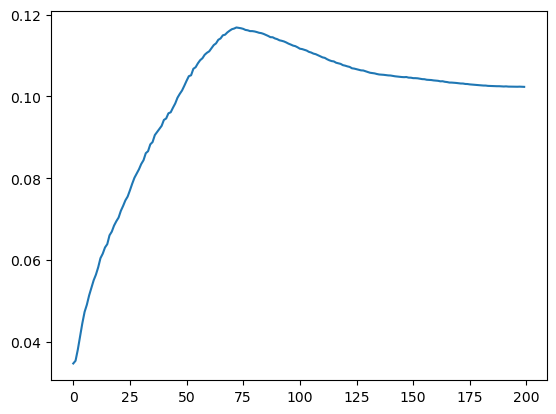

In [25]:
plt.plot(each_adv_gen_mse.cpu().detach().numpy())

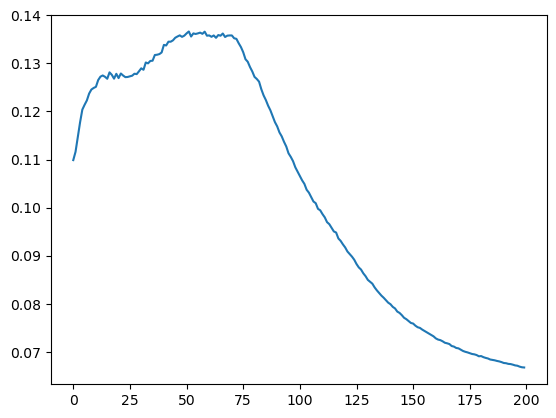

In [26]:
plt.plot(each_fooled_out_mse.cpu().detach().numpy())

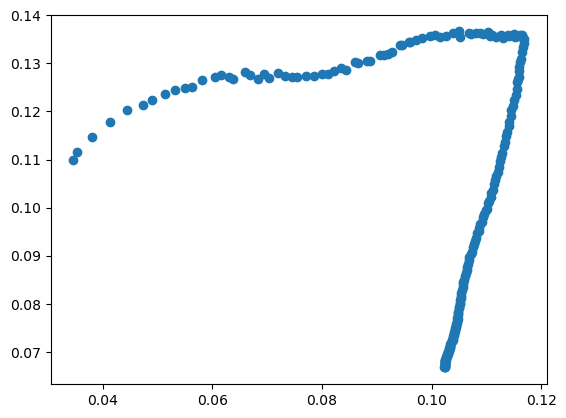

In [27]:
plt.scatter(each_adv_gen_mse.cpu().detach().numpy(), each_fooled_out_mse.cpu().detach().numpy())

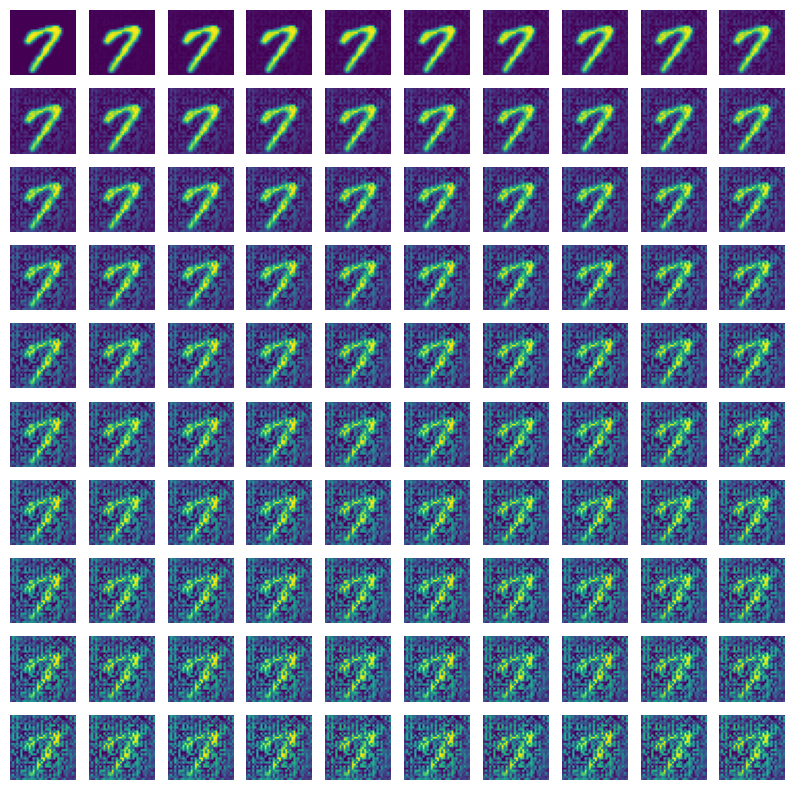

In [28]:
with torch.no_grad():
    fig = plt.figure(figsize=(10,10))
    for i in range(100):
        plt.subplot(10, 10,i+1)
        plt.imshow(scale_noised_images[i][0].cpu().numpy())
        plt.axis('off')
    plt.show()

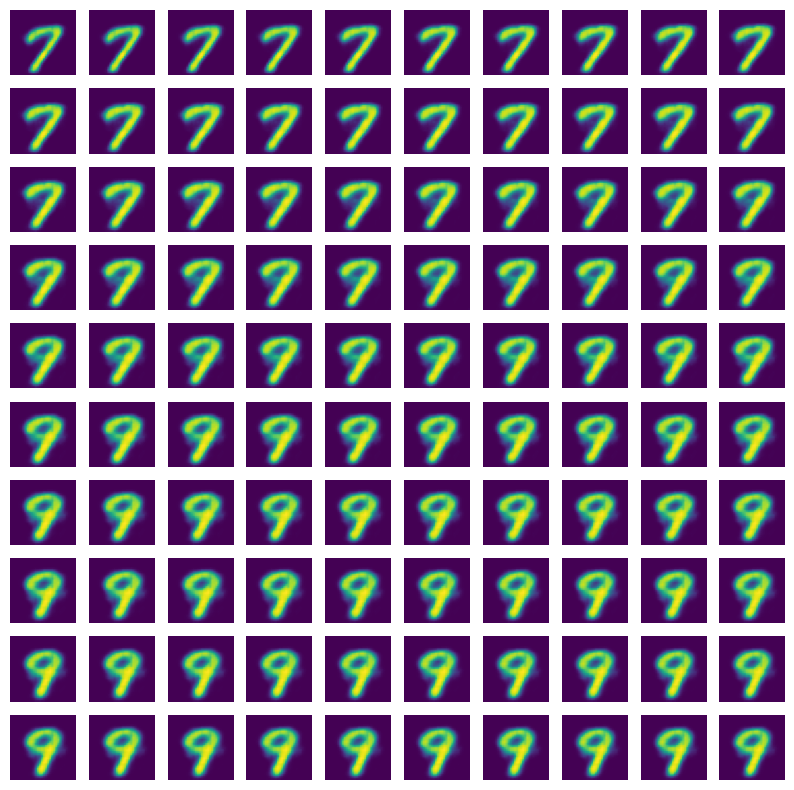

In [29]:
with torch.no_grad():
    fig = plt.figure(figsize=(10,10))
    for i in range(100):
        plt.subplot(10, 10,i+1)
        plt.imshow(adv_gen[i][0].cpu().numpy())
        plt.axis('off')
    plt.show()

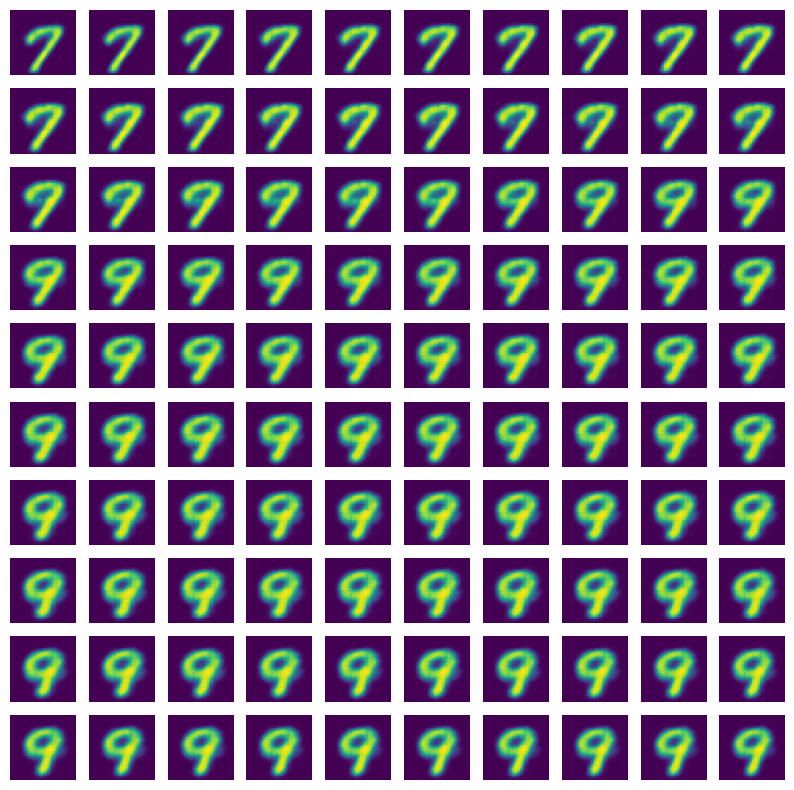

In [30]:
with torch.no_grad():
    fig = plt.figure(figsize=(10,10))
    for i in range(100):
        plt.subplot(10, 10,i+1)
        plt.imshow(fooled_out[i][0].cpu().numpy())
        plt.axis('off')
    plt.show()

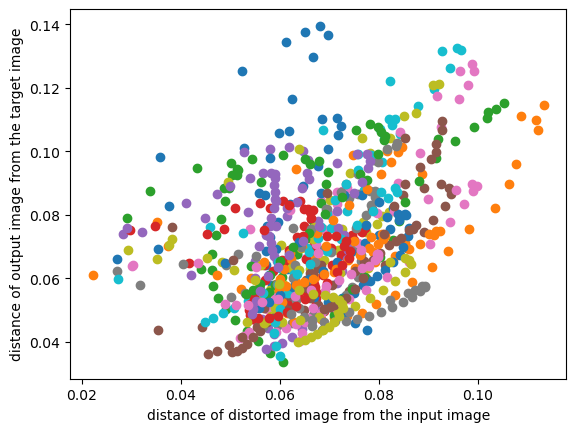

In [31]:
num_steps = 20
path = torch.linspace(0.0, 1.0, num_steps).to(device)

nth_image_ind = 0

critical_inds_list = []

all_selected_adv_gens = torch.tensor([]).to(device)

for nth_image_ind in range(viz_train.shape[0]):

    n_th_image = viz_train[nth_image_ind].unsqueeze(0)
    n_th_adv_image = viz_adv[nth_image_ind].unsqueeze(0)


    noise_outputs = autoenoiser_cnn(n_th_image)
    noise_outputs = (noise_outputs - 1.0)*2.0

    so_many_zeros = torch.zeros(num_steps, 1, 32, 32).to(device)
    scales = so_many_zeros + path.view(num_steps, 1, 1, 1)  

    scaled_noises = noise_outputs * scales

    scale_noised_images = n_th_image + scaled_noises

    adv_gen,_,_ = model_cnnvae_(scale_noised_images)
    
    
    #diff = torch.sqrt((adv_gen - n_th_image)**2)
    each_adv_gen_mse = torch.sqrt((adv_gen - n_th_image)**2).mean(dim=(2, 3), keepdim=True).squeeze()
    #each_adv_gen_mse = torch.sqrt((adv_gen - adv_gen[0].unsqueeze(0))**2).mean(dim=(2, 3), keepdim=True).squeeze()
    #print("each_adv_gen_mse.shape", each_adv_gen_mse.shape)
    fooled_out, _, _= model_cnnvae_(adv_gen)

    each_fooled_out_mse = torch.sqrt((fooled_out - n_th_adv_image)**2).mean(dim=(2, 3), keepdim=True).squeeze()
    #each_fooled_out_mse = torch.sqrt((fooled_out - fooled_out[-1].unsqueeze(0))**2).mean(dim=(2, 3), keepdim=True).squeeze()

    bool_mix = (each_adv_gen_mse < 0.06) * (each_fooled_out_mse < 0.07)



    if(True in bool_mix):
        #print("bool_mix ", bool_mix )
        selected_adv_gens = adv_gen[bool_mix]
        #print("selected_adv_gens.shape", selected_adv_gens.shape)
        all_selected_adv_gens = torch.cat((all_selected_adv_gens, selected_adv_gens))
        #print("all_selected_adv_gens.shape", all_selected_adv_gens.shape)
        critical_inds_list.append(nth_image_ind)
        plt.scatter(each_adv_gen_mse.cpu().detach().numpy(), each_fooled_out_mse.cpu().detach().numpy())
    plt.xlabel("distance of distorted image from the input image")
    plt.ylabel("distance of output image from the target image")

In [32]:
len(critical_inds_list)

39

In [33]:
all_selected_adv_gens.shape

torch.Size([151, 1, 32, 32])

In [34]:
#torch.save(all_selected_adv_gens, "/home/luser/representation-learning-of-unbalanced-datasets/saved_adversarial_samples/adv_shirts_bags.pt")

In [35]:
#all_selected_adv_gens = torch.load("/home/luser/representation-learning-of-unbalanced-datasets/saved_adversarial_samples/adv_pants.pt")
#all_selected_adv_gens = torch.load("/home/luser/representation-learning-of-unbalanced-datasets/saved_adversarial_samples/adv_shirts_bags.pt")

In [36]:
fooled_out_act, _, _= model_cnnvae_(all_selected_adv_gens)


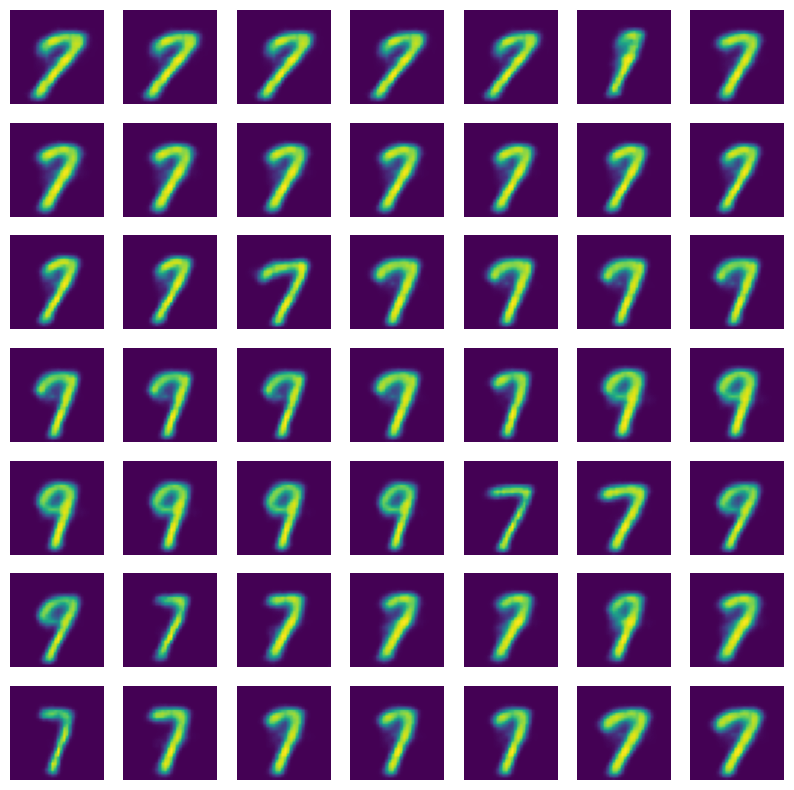

In [37]:
with torch.no_grad():
    fig = plt.figure(figsize=(10,10))
    for i in range(49):
        plt.subplot(7, 7,i+1)
        plt.imshow(all_selected_adv_gens[i][0].cpu().numpy())
        plt.axis('off')
    plt.show()

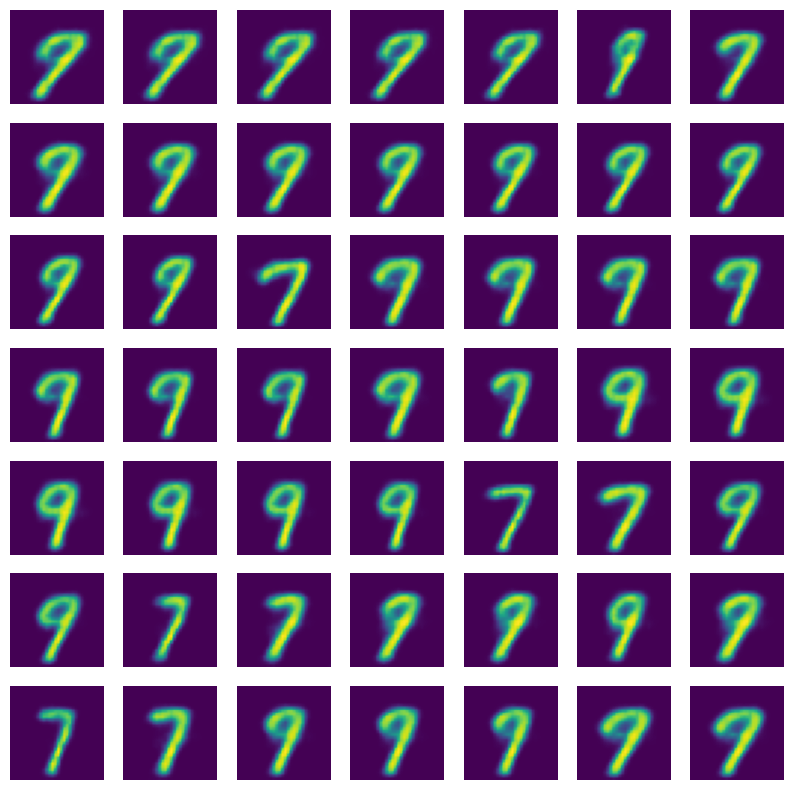

In [38]:
with torch.no_grad():
    fig = plt.figure(figsize=(10,10))
    for i in range(49):
        plt.subplot(7, 7,i+1)
        plt.imshow(fooled_out_act[i][0].cpu().numpy())
        plt.axis('off')
    plt.show()

In [43]:
import ot


2023-11-13 19:53:52.539718: I tensorflow/stream_executor/platform/default/dso_loader.cc:49] Successfully opened dynamic library libcudart.so.10.1
2023-11-13 19:53:53.670765: I tensorflow/compiler/jit/xla_cpu_device.cc:41] Not creating XLA devices, tf_xla_enable_xla_devices not set
2023-11-13 19:53:53.670854: I tensorflow/stream_executor/platform/default/dso_loader.cc:49] Successfully opened dynamic library libcuda.so.1
2023-11-13 19:53:53.670962: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:941] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-11-13 19:53:53.672286: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1720] Found device 0 with properties: 
pciBusID: 0000:13:00.0 name: NVIDIA A100 80GB PCIe computeCapability: 8.0
coreClock: 1.41GHz coreCount: 108 deviceMemorySize: 79.15GiB deviceMemoryBandwidth: 1.76TiB/s
2023-11-13 19:53:53.672337: I tensorflow/stream_executor/cuda/cuda_gpu_

# Same thing with wasserstein distance

In [170]:
num_steps = 200
path = torch.linspace(0.0, 1.0, num_steps).to(device)

nth_image_ind = 0

critical_inds_list = []

all_selected_adv_gens = torch.tensor([]).to(device)

for nth_image_ind in range(viz_train.shape[0]):

    n_th_image = viz_train[nth_image_ind].unsqueeze(0)
    n_th_adv_image = viz_adv[nth_image_ind].unsqueeze(0)


    noise_outputs = autoenoiser_cnn(n_th_image)
    noise_outputs = (noise_outputs - 1.0)*2.0

    so_many_zeros = torch.zeros(num_steps, 1, 32, 32).to(device)
    scales = so_many_zeros + path.view(num_steps, 1, 1, 1)  

    scaled_noises = noise_outputs * scales

    scale_noised_images = n_th_image + scaled_noises

    adv_gen,_,_ = model_cnnvae_(scale_noised_images)
    #print("adv_gen.shape", adv_gen.shape)
    #print("n_th_image.shape", n_th_image.shape)

    #diff = torch.sqrt((adv_gen - n_th_image)**2)
    #each_adv_gen_mse = torch.sqrt((adv_gen - n_th_image)**2).mean(dim=(2, 3), keepdim=True).squeeze()

    #print("adv_gen.shape", adv_gen.shape)
    #print("n_th_image.shape", n_th_image.shape)
    
    all_adv_gen_wassDistance = torch.tensor([]).to(device)
    for i in range(len(adv_gen)):
        #each_adv_gen_wassDistance = ot.sliced_wasserstein_distance(adv_gen[i][0], n_th_image[0][0], seed=0)  
        each_adv_gen_wassDistance = ot.sliced_wasserstein_distance(adv_gen[i][0], adv_gen[0][0], seed=0)  
        all_adv_gen_wassDistance = torch.cat((all_adv_gen_wassDistance, each_adv_gen_wassDistance.unsqueeze(0)))
    #print("all_adv_gen_wassDistance.shape", all_adv_gen_wassDistance.shape)
    

    #print("each_adv_gen_mse.shape", each_adv_gen_mse.shape)
    fooled_out= model_cnnae(adv_gen)

    #print("fooled_out.shape", fooled_out.shape)

    #each_fooled_out_mse = torch.sqrt((fooled_out - n_th_adv_image)**2).mean(dim=(2, 3), keepdim=True).squeeze()

    all_fooled_out_wassDistance = torch.tensor([]).to(device)
    for i in range(len(fooled_out)):
        #each_fooled_out_wassDistance = ot.sliced_wasserstein_distance(fooled_out[i][0], n_th_adv_image[0][0], seed=0)  
        each_fooled_out_wassDistance = ot.sliced_wasserstein_distance(fooled_out[i][0], fooled_out[-1][0], seed=0)  
        all_fooled_out_wassDistance = torch.cat((all_fooled_out_wassDistance, each_fooled_out_wassDistance.unsqueeze(0)))
    #print("all_adv_gen_wassDistance.shape", all_fooled_out_wassDistance.shape)


    #plt.scatter(all_adv_gen_wassDistance.cpu().detach().numpy(), all_fooled_out_wassDistance.cpu().detach().numpy())

    bool_mix = (all_adv_gen_wassDistance < 0.003) * (all_fooled_out_wassDistance < 0.003)

    if(True in bool_mix):
        #print("bool_mix ", bool_mix )
        selected_adv_gens = adv_gen[bool_mix]
        #print("selected_adv_gens.shape", selected_adv_gens.shape)
        all_selected_adv_gens = torch.cat((all_selected_adv_gens, selected_adv_gens))
        #print("all_selected_adv_gens.shape", all_selected_adv_gens.shape)
        critical_inds_list.append(nth_image_ind)
        plt.scatter(all_adv_gen_wassDistance.cpu().detach().numpy(), all_fooled_out_wassDistance.cpu().detach().numpy())

In [171]:
all_selected_adv_gens.shape

torch.Size([0])

In [172]:
fooled_out_act= model_cnnae(all_selected_adv_gens)


RuntimeError: Expected 3D (unbatched) or 4D (batched) input to conv2d, but got input of size: [0]

IndexError: index 0 is out of bounds for dimension 0 with size 0

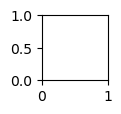

In [173]:
with torch.no_grad():
    fig = plt.figure(figsize=(10,10))
    for i in range(100):
        plt.subplot(10, 10,i+1)
        plt.imshow(all_selected_adv_gens[i][0].cpu().numpy())
        plt.axis('off')
    plt.show()

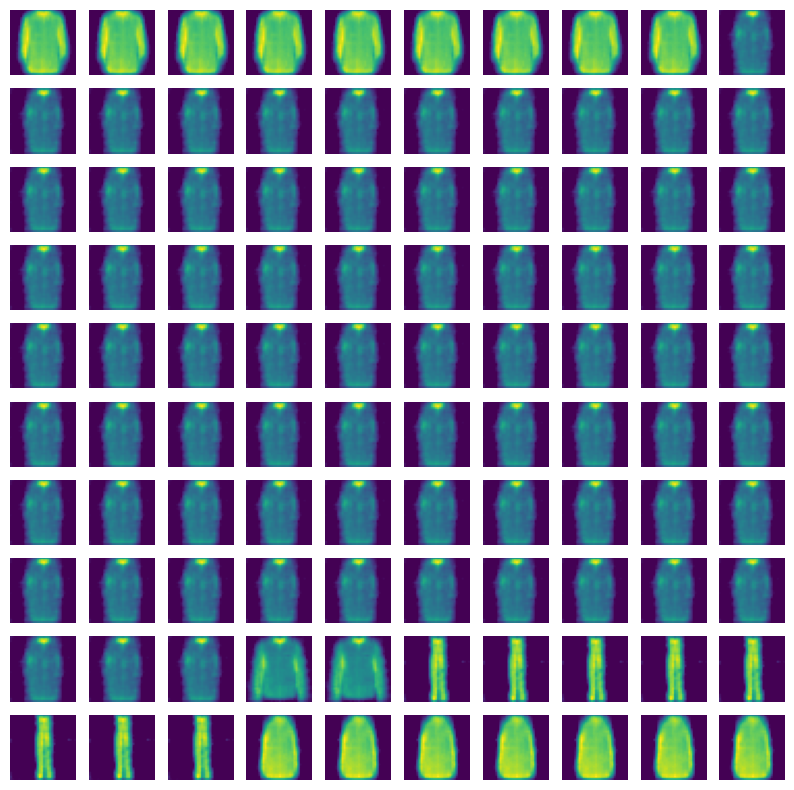

In [62]:
with torch.no_grad():
    fig = plt.figure(figsize=(10,10))
    for i in range(100):
        plt.subplot(10, 10,i+1)
        plt.imshow(fooled_out_act[i][0].cpu().numpy())
        plt.axis('off')
    plt.show()

In [46]:
activation_cnn_noiser = nn.ReLU()
all_class_batches_list= [class_0_images, class_1_images, class_2_images, class_3_images, class_4_images, class_5_images, class_6_images, class_7_images, class_8_images, class_9_images]
autoenoiser_cnn = CNN_AE_fmnist_noiser_2sig(latent_dim, no_channels, activation_cnn_noiser).to(device)
#input_class = 0
#target_class = 0

In [47]:
autoenoiser_cnn.load_state_dict(torch.load('/home/luser/representation-learning-of-unbalanced-datasets/saved_noiser_single_models_with_2sigmoid_mult/model_sp_autoenoiser_cnn_class_'+str(input_class)+'_to_class_'+str(target_class)+'', map_location=device))

FileNotFoundError: [Errno 2] No such file or directory: '/home/luser/representation-learning-of-unbalanced-datasets/saved_noiser_single_models_with_2sigmoid_mult/model_sp_autoenoiser_cnn_class_3_to_class_3'

# Finding the counterfactuals through smooth transition along a trajectory

In [ ]:
num_steps = 20

path = np.linspace(1.0, 0.0, num_steps)

along_adv_gen = []
along_noised_inputs = []
along_normal_out = []
along_fooled_out= []

#input_batch = all_class_batches_list[input_class][selected_index_in_input_batch].reshape(-1, no_channels, dx, dy).to(device)
input_batch = train_batches_
target_batch = all_class_batches_list[target_class][selected_index_in_input_batch].reshape(-1, no_channels, dx, dy).to(device)

print(input_batch.shape)

adv_fool_loss_list = []
adv_input_loss_list = []

for step in path:

    #print("input_batch.shape", input_batch.shape)
    #print("target_batch.shape", target_batch.shape)
    noise_generated = autoenoiser_cnn(input_batch)
    #print(noiser.shape)
    #noised_inputs = input_batch *  noise_generated
    #print("noise_generated.shape", noise_generated.shape)

    after_reduction = noise_generated 

    #print("after_reduction.max(), after_reduction.min()", after_reduction.max(), after_reduction.min())

    noised_inputs = input_batch *  (after_reduction + step * (1- after_reduction))

    adv_gen, _, _ = model_cnnvae_(noised_inputs)

    fooled_out = model_cnnae(adv_gen)

    normal_out = model_cnnae(input_batch)

    #print("targeted_outs.shape", adv_gen.shape)
    #print("untarget_outs.shape", normal_out.shape)

    adv_fool_loss = criterion(adv_gen, fooled_out)
    adv_input_loss = criterion(adv_gen, input_batch)

    adv_fool_loss_list.append(adv_fool_loss.item())
    adv_input_loss_list.append(adv_input_loss.item())


    along_adv_gen.append(adv_gen[0].unsqueeze(0))
    along_fooled_out.append(fooled_out[0].unsqueeze(0))
    along_normal_out.append(normal_out[0].unsqueeze(0))
    along_noised_inputs.append(noised_inputs[0].unsqueeze(0))

NameError: name 'selected_index_in_input_batch' is not defined

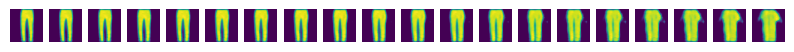

In [ ]:
with torch.no_grad():
    fig = plt.figure(figsize=(10,10))
    for i in range(len(path)):
        plt.subplot(1, num_steps,i+1)
        plt.imshow(along_adv_gen[i].reshape(32,32).cpu().numpy())
        plt.axis('off')
plt.show()

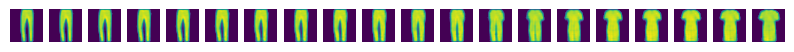

In [ ]:
with torch.no_grad():
    fig = plt.figure(figsize=(10,10))
    for i in range(len(path)):
        plt.subplot(1, num_steps,i+1)
        plt.imshow(along_fooled_out[i].reshape(32,32).cpu().numpy())
        plt.axis('off')
plt.show()

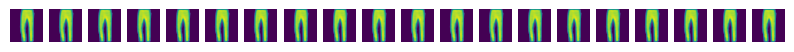

In [ ]:
with torch.no_grad():
    fig = plt.figure(figsize=(10,10))
    for i in range(len(path)):
        plt.subplot(1, num_steps,i+1)
        plt.imshow(along_normal_out[i].reshape(32,32).cpu().numpy())
        plt.axis('off')
plt.show()

along_noised_inputs[i][0][0].max() tensor(0.9725, device='cuda:0')
along_noised_inputs[i][0][0].max() tensor(1.0113, device='cuda:0')
along_noised_inputs[i][0][0].max() tensor(1.0619, device='cuda:0')
along_noised_inputs[i][0][0].max() tensor(1.1125, device='cuda:0')
along_noised_inputs[i][0][0].max() tensor(1.1630, device='cuda:0')
along_noised_inputs[i][0][0].max() tensor(1.2136, device='cuda:0')
along_noised_inputs[i][0][0].max() tensor(1.2641, device='cuda:0')
along_noised_inputs[i][0][0].max() tensor(1.3147, device='cuda:0')
along_noised_inputs[i][0][0].max() tensor(1.3652, device='cuda:0')
along_noised_inputs[i][0][0].max() tensor(1.4158, device='cuda:0')
along_noised_inputs[i][0][0].max() tensor(1.4664, device='cuda:0')
along_noised_inputs[i][0][0].max() tensor(1.5169, device='cuda:0')
along_noised_inputs[i][0][0].max() tensor(1.5675, device='cuda:0')
along_noised_inputs[i][0][0].max() tensor(1.6180, device='cuda:0')
along_noised_inputs[i][0][0].max() tensor(1.6686, device='cuda

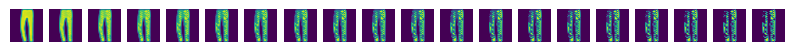

In [ ]:
with torch.no_grad():
    fig = plt.figure(figsize=(10,10))
    for i in range(len(path)):
        plt.subplot(1, num_steps,i+1)
        plt.imshow(along_noised_inputs[i][0][0].cpu().numpy())
        print("along_noised_inputs[i][0][0].max()", along_noised_inputs[i][0][0].max())
        plt.axis('off')
plt.show()

In [ ]:
adv_fool_loss_list

[0.0017157354159280658,
 0.0019428329542279243,
 0.002359498292207718,
 0.00267551327124238,
 0.0028220079839229584,
 0.0027712800074368715,
 0.0026600416749715805,
 0.0024674651212990284,
 0.0022718189284205437,
 0.0021293964236974716,
 0.002123708836734295,
 0.0021575186401605606,
 0.003141874447464943,
 0.006014344282448292,
 0.009480301290750504,
 0.011688055470585823,
 0.011992366053164005,
 0.010876799002289772,
 0.009326442144811153,
 0.008395107463002205]

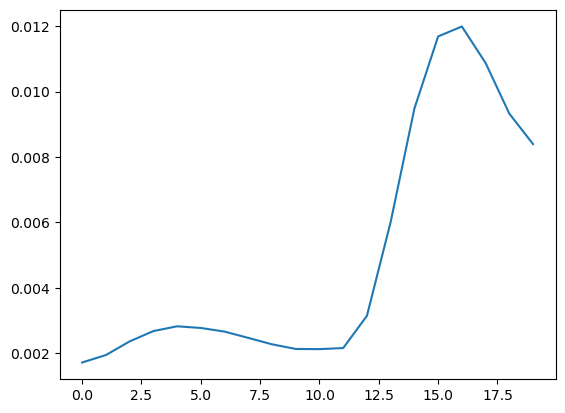

In [ ]:
plt.plot(adv_fool_loss_list)

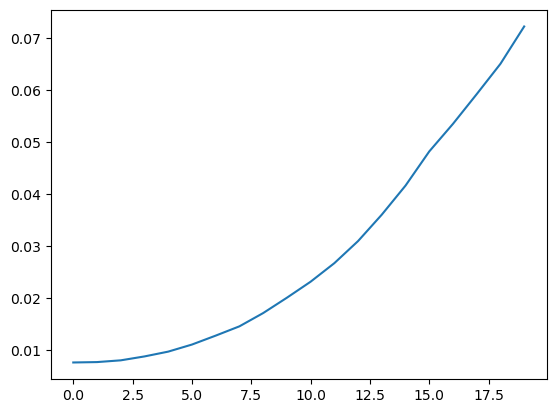

In [ ]:
plt.plot(adv_input_loss_list)

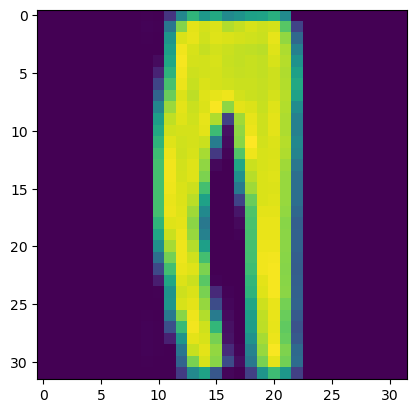

In [ ]:
with torch.no_grad():
    plt.imshow(input_batch[0][0].cpu().numpy())

In [ ]:
step = 0.0
noise_generated = autoenoiser_cnn(input_batch)
noised_inputs = input_batch *  (noise_generated + step * (1- noise_generated))

adv_gen, _, _ = model_cnnvae_(noised_inputs)

fooled_out, _, _ = model_cnnvae_(adv_gen)



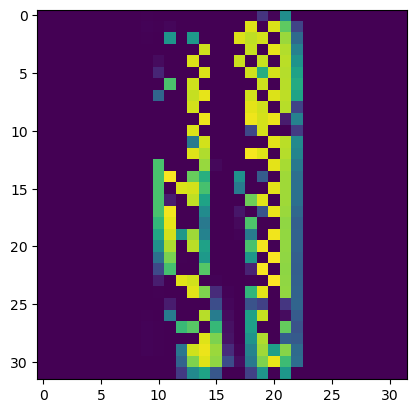

In [ ]:
with torch.no_grad():
    plt.imshow(noised_inputs[0][0].cpu().numpy())

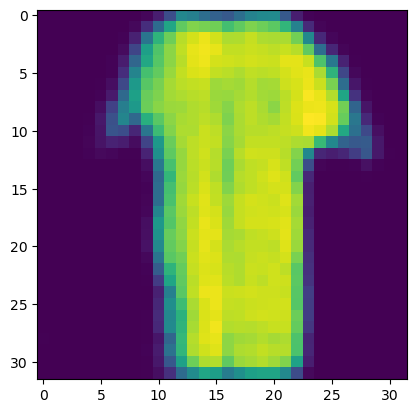

In [ ]:
with torch.no_grad():
    plt.imshow(adv_gen[0][0].cpu().numpy())

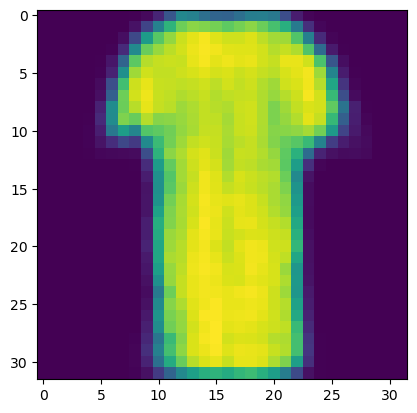

In [ ]:
with torch.no_grad():
    plt.imshow(fooled_out[0][0].cpu().numpy())